In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_dir = os.path.dirname(notebook_dir)

if project_dir not in sys.path:
    sys.path.insert(0, project_dir)
import matplotlib.pyplot as plt
from matplotlib import gridspec

import torch, torch.nn as nn
import seaborn as sns
import logging
import snntorch as snn
import numpy as np
import random
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets

logging.getLogger().setLevel(logging.INFO)
%load_ext autoreload
%autoreload 2

In [2]:
# Define Network
class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, timesteps:int,
                enc_tau:float, threshold:float, dt:float=10e-3,
                tau_adapt:float=100e-3, threshold_weight:float=1.0):
        super().__init__()
        self.dt = dt
        self.enc_beta = torch.exp(-torch.tensor(dt) / torch.tensor(enc_tau))

        self.base_threshold = threshold
        self.timesteps = timesteps
        # initialize layers
        self.fc1 = nn.Linear(num_inputs, num_outputs, bias=False)
        self.fc1.weight = nn.Parameter(torch.eye(num_inputs) * 1.0)
        # self.fc1.bias = nn.Parameter(torch.zeros(num_outputs))

         # ALIF neuron layer
        self.encoding_layer = snn.ALeaky(beta=self.enc_beta,
                                        threshold=self.base_threshold,
                                        learn_beta=False,
                                        learn_threshold=False,
                                        reset_mechanism="zero",
                                        tau_adapt=tau_adapt,
                                        threshold_weight=threshold_weight,
                                        dt=dt)

        self.leaky = snn.Leaky(beta=self.enc_beta,
                                threshold=self.base_threshold,
                                learn_beta=False,
                                learn_threshold=False,
                                reset_mechanism="zero")
        
        # set random seed for reproducibility
        seed = 4
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)


        
    def forward(self, x):
        enc_neu_mem, threshold_adapt = self.encoding_layer.init_aleaky()
        mem2 = self.leaky.init_leaky()
        # print(f"Initial threshold:{threshold_adapt}")
         # record variables
        rec_vars = {'mem': [], 'spk': [], 'threshold_adapt': [], 'threshold': [], 'mem2': [], 'spk2': []}
        for step in range(self.timesteps):
            cur1 = self.fc1(x[:,step])
            spk1, enc_neu_mem, threshold_adapt, threshold = self.encoding_layer(cur1, enc_neu_mem, threshold_adapt)

            spk2,mem2 = self.leaky(cur1, mem2)

            rec_vars['mem'].append(enc_neu_mem)
            rec_vars['spk'].append(spk1)
            rec_vars['threshold_adapt'].append(threshold_adapt)
            rec_vars['threshold'].append(threshold)
            rec_vars['mem2'].append(mem2)
            rec_vars['spk2'].append(spk2)
        
        # Stack
            # stack the recorded variables
        for var in rec_vars:
            rec_vars[var] = torch.stack(rec_vars[var], dim=1)
        return rec_vars

In [3]:
net = Net(num_inputs=1, num_outputs=1, timesteps=100, enc_tau=20e-3, 
          threshold=1.0, dt=10e-3,
          tau_adapt=100e-3, threshold_weight=1)

# Generate a constant input current for 100 time steps
num_steps = 100
input_current = torch.ones((1, num_steps)) * 0.6 # shape: (batch_size, num_steps)
rec_vars = net(input_current)
# print("Final Membrane Potential:", mem)
# print("Final Spike Output:", spk)
print(rec_vars['spk'].detach().cpu())

print(rec_vars['spk2'].detach().cpu())
# rec_vars['mem2'].detach().cpu().numpy(

tensor([[0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
         0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1.,
         0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
         0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1.,
         0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
         0., 1., 0., 0., 0., 1., 0., 0., 0., 1.]])
tensor([[0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1.,
         0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1.,
         0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1.,
         0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1.,
         0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1.,
         0., 0., 1., 0., 0., 1., 0., 0., 1., 0.]])


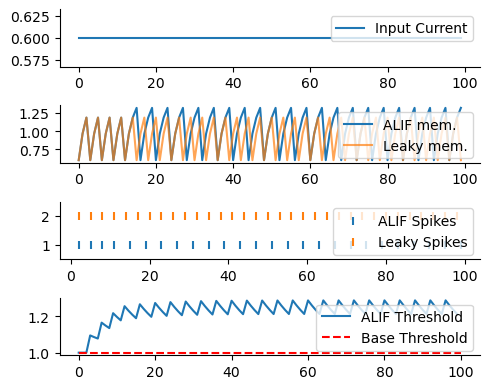

In [4]:
# PLot input current, mem and spikes
fig = plt.figure(figsize=(5, 4))
gs = gridspec.GridSpec(4, 1)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[2, 0])
ax3 = fig.add_subplot(gs[3, 0])

ax0.plot(np.arange(num_steps), input_current.T, label='Input Current')
ax0.legend()
sns.despine(ax=ax0)

ax1.plot(np.arange(num_steps), rec_vars['mem'].detach().cpu().numpy().T, label='ALIF mem.')
ax1.plot(np.arange(num_steps), rec_vars['mem2'].detach().cpu().numpy().T, label='Leaky mem.', alpha=0.7)
ax1.legend()
sns.despine(ax=ax1)

spike_times = np.where(rec_vars['spk'].detach().cpu().numpy().T > 0)[0]
spike_times2 = np.where(rec_vars['spk2'].detach().cpu().numpy().T > 0)[0]

ax2.scatter(spike_times, np.ones_like(spike_times), label='ALIF Spikes', marker='|')
ax2.scatter(spike_times2, np.ones_like(spike_times2)*2, label='Leaky Spikes', marker='|')

ax2.set_ylim([0.5, 2.5])
ax2.legend()
sns.despine(ax=ax2)

ax3.plot(np.arange(num_steps), rec_vars['threshold'].detach().cpu().numpy().T, label='ALIF Threshold')
ax3.hlines(y=net.base_threshold, xmin=0, xmax=num_steps, colors='r', linestyles='--', label='Base Threshold')
ax3.legend()
sns.despine(ax=ax3)

fig.tight_layout()

# Using interactive sliders

In [5]:
# color palette
COLORS = {
    'burgundy': '#610933',
    'pumpkin': '#d35400',
    'midnight_blue': '#2c3e50',
    'pomgrenate': '#c0392b',
    'green_sea': '#16a085',
    'wisteria': '#8e44ad',
    'orange': '#f39c12',
    'clouds': '#7f8c8d',
    'naval': '#40739e',
    'purple': '#8c7ae6',
    'viz_orange': '#fa8775',
    'belize': '#2980b9',
    'cherry': '#99004c',
    'blueberry': '#0066cc',
    # from https://personal.sron.nl/~pault/#sec:qualitative
    'cyan': '#66CCEE',
    'forest_green': '#228833',
    'pink_red': '#BB5566',
    'mustard': '#DDAA33',
    'blue': '#4477AA',
    'cherry_red': '#B90047',
    'orange_red': '#FF5E45',
    'bright_yellow': '#FBED99',
    'turquoise': '#7BC2A6',
    'sky_blue': '#2290D0',
}

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import FloatSlider, FloatText, IntText, HBox, VBox

# ----------------------------------------
# Simulation function
# ----------------------------------------
def run_sim(
    threshold=1.0,
    tau_adapt=100,
    threshold_weight=1.0,
    enc_tau=20,
    input_amp=0.6,
    pulse_on_steps=100,
    pulse_start_step=0,
    pulse2_start_step=50,   # NEW: second pulse start
):
    """
    Run a simple ALIF vs Leaky neuron simulation and plot:
      1) input current
      2) membrane potential (ALIF + Leaky)
      3) spike times
      4) adaptive threshold

    Parameters:
      - threshold: base threshold (a.u.)
      - tau_adapt: adaptation time constant (ms)
      - threshold_weight: adaptation jump per spike
      - enc_tau: encoding / membrane tau (ms)
      - input_amp: amplitude of both input pulses (a.u.)
      - pulse_on_steps: number of time steps where each pulse is ON
      - pulse_start_step: start step of first pulse
      - pulse2_start_step: start step of second pulse
    """

    # create network with chosen hyperparameters
    net = Net(
        num_inputs=1,
        num_outputs=1,
        timesteps=100,
        enc_tau=enc_tau * 10e-3,
        threshold=threshold,
        dt=10e-3,
        tau_adapt=tau_adapt * 10e-3,
        threshold_weight=threshold_weight
    )

    # generate pulsed input current
    num_steps = 100
    input_current = torch.zeros((1, num_steps))

    on_steps = int(max(pulse_on_steps, 0))

    # ----- Pulse 1 -----
    start1 = int(max(pulse_start_step, 0))
    start1 = min(start1, num_steps)
    end1 = min(start1 + on_steps, num_steps)
    if end1 > start1:
        input_current[:, start1:end1] = input_amp

    # ----- Pulse 2 (same amp & duration, different start) -----
    start2 = int(max(pulse2_start_step, 0))
    start2 = min(start2, num_steps)
    end2 = min(start2 + on_steps, num_steps)
    if end2 > start2:
        input_current[:, start2:end2] = input_amp

    # run simulation
    rec = net(input_current)

    mem_alif = rec["mem"].detach().cpu().numpy()[0]
    thr_alif = rec["threshold"].detach().cpu().numpy()[0]
    spk_alif_times = np.where(rec['spk'].detach().cpu().numpy().T > 0)[0]

    mem_leaky = rec["mem2"].detach().cpu().numpy()[0]
    spk_leaky_times = np.where(rec['spk2'].detach().cpu().numpy().T > 0)[0]

    # plotting
    plt.figure(figsize=(10, 6))

    # 1) Input
    plt.subplot(4, 1, 1)
    plt.plot(input_current.T)
    plt.title(
        f"Input current: amp={input_amp:.2f}, "
        f"pulse1 start={start1}, pulse2 start={start2}, "
        f"duration={on_steps} steps"
    )
    plt.ylabel("I(t)")

    # 2) Membrane potentials
    plt.subplot(4, 1, 2)
    plt.plot(mem_alif, label="ALIF mem.")
    plt.plot(mem_leaky, label="Leaky mem.", linestyle="--")
    plt.hlines(
        y=threshold, xmin=0, xmax=num_steps,
        colors='g', linestyles='--',
        label='Base threshold', alpha=0.5
    )
    plt.ylabel("Membrane")
    plt.title("Membrane Potential")
    plt.legend()

    # 3) Spikes
    plt.subplot(4, 1, 3)
    plt.scatter(spk_alif_times, np.ones_like(spk_alif_times),
                label='ALIF spikes', marker='|')
    plt.scatter(spk_leaky_times, np.ones_like(spk_leaky_times) * 2,
                label='Leaky spikes', marker='|')
    plt.xlim(-5, num_steps + 5)
    plt.ylabel("Spike")
    plt.ylim(-0.1, 2.5)
    plt.yticks([1, 2], ["ALIF", "Leaky"])
    plt.title("Spike Train")

    # 4) Adaptive threshold
    plt.subplot(4, 1, 4)
    plt.plot(thr_alif, label="ALIF threshold")
    plt.hlines(
        y=net.base_threshold, xmin=0, xmax=num_steps,
        colors='r', linestyles='--', label='Base threshold'
    )
    plt.ylabel("Threshold")
    plt.xlabel("Time step")
    plt.title("Adaptive Threshold")
    plt.legend()

    plt.tight_layout()
    plt.show()


# ----------------------------------------
# Helper: create a slider + text box pair
# ----------------------------------------
def slider_with_text(description, min_val, max_val, step, value):
    slider = FloatSlider(
        min=min_val,
        max=max_val,
        step=step,
        value=value,
        description=description,
        layout=widgets.Layout(width='350px'),
        style={'description_width': '180px'}
    )
    text = FloatText(
        value=value,
        layout=widgets.Layout(width='120px')
    )

    widgets.jslink((slider, 'value'), (text, 'value'))
    return HBox([slider, text]), slider


# ----------------------------------------
# Build the controls: sliders + text fields
# ----------------------------------------

threshold_box, threshold_slider = slider_with_text(
    "Base thres. (a.u.)", min_val=0.1, max_val=20, step=0.05, value=2
)
tau_box, tau_slider = slider_with_text(
    "Thres. tau Adapt (ms)", min_val=10, max_val=500, step=10, value=10
)
weight_box, weight_slider = slider_with_text(
    "Threshold weight", min_val=0, max_val=20, step=0.1, value=2
)
enc_tau_box, enc_tau_slider = slider_with_text(
    "tau mem (ms)", min_val=1, max_val=100, step=1, value=20
)

# input current controls
input_amp_text = FloatText(
    value=0.6,
    description="Input amp (a.u.)",
    layout=widgets.Layout(width='250px'),
    style={'description_width': '150px'}
)

pulse_on_text = IntText(
    value=10,
    description="Pulse ON (steps)",
    layout=widgets.Layout(width='250px'),
    style={'description_width': '150px'}
)

pulse_start_text = IntText(
    value=0,
    description="Pulse1 start (step)",
    layout=widgets.Layout(width='250px'),
    style={'description_width': '150px'}
)

pulse2_start_text = IntText(      # NEW text box
    value=50,
    description="Pulse2 start (step)",
    layout=widgets.Layout(width='250px'),
    style={'description_width': '150px'}
)

input_box = HBox([
    input_amp_text,
    pulse_on_text,
    pulse_start_text,
    pulse2_start_text,
])

# ----------------------------------------
# Hook controls to the simulation
# ----------------------------------------
controls = VBox([
    threshold_box,
    tau_box,
    weight_box,
    enc_tau_box,
    widgets.Label("Input current settings:"),
    input_box
])

out = widgets.interactive_output(
    run_sim,
    {
        'threshold': threshold_slider,
        'tau_adapt': tau_slider,
        'threshold_weight': weight_slider,
        'enc_tau': enc_tau_slider,
        'input_amp': input_amp_text,
        'pulse_on_steps': pulse_on_text,
        'pulse_start_step': pulse_start_text,
        'pulse2_start_step': pulse2_start_text,
    }
)

display(controls, out)

Output()

# Create a simple ALIF vs LEAKY FI curves


In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------------------------------------------------
# FI-curve simulation for ALIF + Leaky neurons
# ---------------------------------------------------
def plot_fi_curves(
    threshold=2.0,
    tau_adapt_ms=100.0,
    threshold_weight=2.0,
    enc_tau_ms=20.0,
    dt_ms=10.0,
    num_steps=100,
    pulse_on_steps=50,
    amp_min=0.0,
    amp_max=1.5,
    n_amps=20,
):
    """
    Compute and plot FI curves for ALIF and Leaky neurons in your Net.

    Firing rate is computed as:
        spike_count / (pulse_duration_sec)

    The input current is a single pulse:
        I(t) = amp,   for t in [0, pulse_on_steps)
             = 0,     otherwise
    """

    # convert ms -> seconds
    dt = dt_ms / 1000.0
    tau_adapt = tau_adapt_ms / 1000.0
    enc_tau = enc_tau_ms / 1000.0

    pulse_duration_sec = pulse_on_steps * dt

    # sweep over amplitudes
    amps = np.linspace(amp_min, amp_max, n_amps)

    rates_alif = []
    rates_leaky = []

    for amp in amps:
        # create fresh network for this amplitude
        net = Net(
            num_inputs=1,
            num_outputs=1,
            timesteps=num_steps,
            enc_tau=enc_tau,
            threshold=threshold,
            dt=dt,
            tau_adapt=tau_adapt,
            threshold_weight=threshold_weight,
        )

        # build input: pulse of length pulse_on_steps
        input_current = torch.zeros((1, num_steps))
        input_current[:, :pulse_on_steps] = amp

        with torch.no_grad():
            rec = net(input_current)

        # ALIF spikes
        spk_alif = rec["spk"].detach().cpu().numpy()
        # shape: (batch, time); we assume batch=1
        spike_count_alif = (spk_alif > 0).sum()
        rate_alif = spike_count_alif / pulse_duration_sec  # Hz

        # Leaky spikes
        spk_leaky = rec["spk2"].detach().cpu().numpy()
        spike_count_leaky = (spk_leaky > 0).sum()
        rate_leaky = spike_count_leaky / pulse_duration_sec  # Hz

        rates_alif.append(rate_alif)
        rates_leaky.append(rate_leaky)

    rates_alif = np.array(rates_alif)
    rates_leaky = np.array(rates_leaky)

    # ---------------------------------------------------
    # Plot FI curves
    # ---------------------------------------------------
    plt.figure(figsize=(6, 4))
    plt.plot(amps, rates_alif, "-o", label="ALIF", alpha=0.8)
    plt.plot(amps, rates_leaky, "-s", label="Leaky", alpha=0.8)

    plt.xlabel("Input amplitude (a.u.)")
    plt.ylabel("Firing rate (Hz)")
    plt.title(
        f"FI curves (pulse: {pulse_on_steps} steps, dt={dt_ms} ms, "
        f"τ_adapt={tau_adapt_ms} ms)"
    )
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()




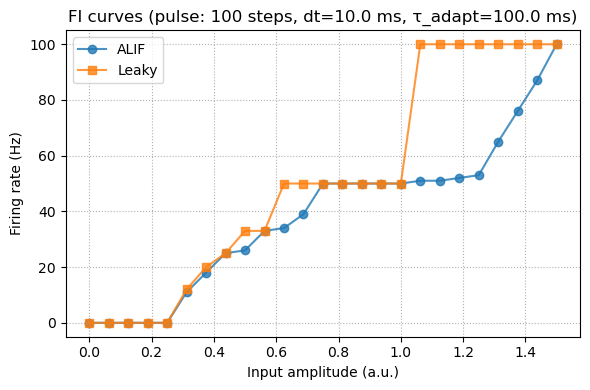

In [8]:
# Example call
plot_fi_curves(
    threshold=1.0,
    tau_adapt_ms=100.0,
    threshold_weight=0.5,
    enc_tau_ms=30.0,
    dt_ms=10.0,
    num_steps=100,
    pulse_on_steps=100,
    amp_min=0.0,
    amp_max=1.5,
    n_amps=25,
)

# Use real EMG data and encode it with ALIF

In [6]:
# add the project directory to the system path
import sys
iemg_project_dir = "/Users/farahbaracat/Documents/PhD Research/Code/force_regression_snn"
sys.path.insert(0, iemg_project_dir)


import srcs.utils.snn_prepare as snn_prep
from srcs.config.dataconfig import DataConfig
import srcs.utils.functions as fn
import pickle as pkl
from torch.utils.data import DataLoader


In [ ]:
torch.zeros((50,1000,120))

In [11]:
root_dir = "/Volumes/big usb drive/local Thin film forearm preprocessed"
root_results_dir = "/Volumes/big usb drive/force_regression_codeshare"
subject_mappings = {
    "AK": "S1",
    "SA": "S2"}

subject = "S1"
mvc = 15
emg_type = 'intra'
sign_mvc = 1
segment_hold=False


In [12]:

data_config = DataConfig(root_dir=root_dir,
                    root_results_dir = root_results_dir,
                    subject=fn.reverse_remap(subject, subject_mappings),
                    task_type="Trap", 
                    finger_type="Individual",
                    day="Day 1", mvc=mvc,
                    emg_type=emg_type,
                    subj_map=subject_mappings,
                    segment_hold=segment_hold,
                    verbose=False,
                    common_only=True,
                    images=True,
                    time_to_cut=1,
                    convreg_temp_data_dir='regression_data',
                    results_dir = 'results',
                    figs_dir = 'figures')

In [13]:
load_from_file = True
emg_force_df = snn_prep.load_emg_data_for_snn(data_config, load_from_file=load_from_file)


INFO:root:Loaded regression data for finger 1
INFO:root:Loaded regression data for finger 2
INFO:root:Loaded regression data for finger 3
INFO:root:Loaded regression data for finger 4
INFO:root:Loaded regression data for finger 5


In [14]:
emg_force_df.iloc[0]['emg_filt_rep1'].shape

(120, 286081)

In [15]:
# load the emg dataset used for the SNN for a single subject
dataset_filename = 'emgdataset_encoding_offline.pkl'
# data_config.subject = fn.reverse_remap('S2', subject_mappings)
dataset_filepath = os.path.join(f"/Volumes/big usb drive/force_regression_codeshare/snn_data/{subject}", dataset_filename)
print(f"Dataset filepath:{dataset_filepath}")
#read the dataset
with open(dataset_filepath, 'rb') as handle:
    dataset = pkl.load(handle)
dataset.num_inputs, dataset.num_outputs, dataset.input.size(), dataset.labels.size()

Dataset filepath:/Volumes/big usb drive/force_regression_codeshare/snn_data/S1/emgdataset_encoding_offline.pkl


(120, 5, torch.Size([50, 1000, 120]), torch.Size([50, 1000, 5]))

In [16]:
n_channels = dataset.num_inputs #emg_force_df.iloc[0]['emg_filt_rep1'].shape[0]
n_channels_per_electrode = n_channels// data_config.n_electrodes
num_steps = dataset.input.size(1)

# Dataset parameters
bin_size = 10
overlap_ratio = 0.5
# LIF encoding parameters
enc_tau_mem = 20e-3
enc_spk_threshold = [0.1]*n_channels_per_electrode + [0.4] * n_channels_per_electrode + [0.2] * n_channels_per_electrode

# ALIF parameters
tau_adapt = 100e-3
threshold_weight = 0.1

In [17]:
dataset.input[0].unsqueeze(0).size(), dataset.rep_dur, dataset.num_segments

(torch.Size([1, 1000, 120]), 27.93759765625, 5)

In [18]:
net = Net(
            num_inputs=n_channels,
            num_outputs=n_channels,
            timesteps=num_steps,
            enc_tau=enc_tau_mem,
            threshold=enc_spk_threshold,
            dt=dataset.dt,
            tau_adapt=tau_adapt,
            threshold_weight=threshold_weight,
        )


In [19]:
dataset.input[0].unsqueeze(0).size(), dataset.input.size()

(torch.Size([1, 1000, 120]), torch.Size([50, 1000, 120]))

In [20]:
batch_size = 10
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [21]:
net(dataset.input[0].unsqueeze(0))['mem2']

tensor([[[0.0042, 0.0189, 0.0026,  ..., 0.0005, 0.0004, 0.0015],
         [0.0122, 0.0300, 0.0027,  ..., 0.0072, 0.0181, 0.0077],
         [0.0420, 0.0588, 0.0350,  ..., 0.0083, 0.0321, 0.0070],
         ...,
         [0.0369, 0.0380, 0.0291,  ..., 0.0643, 0.0588, 0.0475],
         [0.0655, 0.0339, 0.0547,  ..., 0.0838, 0.1216, 0.4277],
         [0.1507, 0.1274, 0.0968,  ..., 0.1062, 0.1400, 0.1471]]],
       grad_fn=<StackBackward0>)

In [ ]:
m= torch.zeros((dataset.input.size(0), dataset.input.size(1), dataset.num_inputs))


In [ ]:
DEVICE = 'cpu'

# Run the network: forward pass
alif_spk_records = []
lif_spk_records = []

alif_spk = torch.zeros((dataset.input.size(0), dataset.input.size(1), dataset.num_inputs))
# lif_spk = torch.zeros((dataset.input.size(0), dataset.input.size(1), dataset.num_inputs)).to(DEVICE)
seg = 0
# for seg in range(dataset.input.size(0)):
rec = net(dataset.input[seg].unsqueeze(0))
    # alif_spk[seg] = rec['spk']
    # alif_spk[seg] = rec['spk']
    # lif_spk[seg] = rec['spk2']
    # alif_spk_records.append(rec['spk'])
        # lif_spk_records.append(rec['spk2'])

In [21]:
# Detach and move to CPU before checking size
alif_spk_records[0].detach().cpu()
# concatenate along batch dimension
# alif_spk_records = torch.cat(alif_spk_records, dim=0)


tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.],
         [1., 0., 0.,  ..., 0., 0., 0.]]])

In [ ]:
# alif_spk_records = torch.cat(alif_spk_records, dim=0)
# lif_spk_records = torch.cat(lif_spk_records, dim=0)
alif_spk_records.size(), lif_spk_records.size()

In [42]:
spike_count_alif = (rec['spk'].detach().cpu().numpy().T > 0).sum()
spike_count_lif = (rec['spk2'].detach().cpu().numpy().T > 0).sum()
print(f"ALIF spike count:{spike_count_alif}, LIF spike count:{spike_count_lif}")


ALIF spike count:6902, LIF spike count:8168


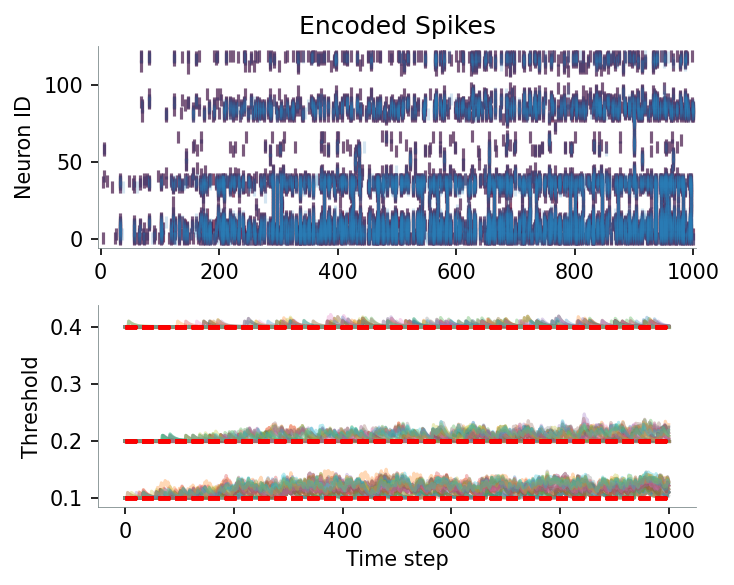

In [53]:
# plotting

input = dataset.input[0].unsqueeze(0)
mem_alif = rec["mem"].detach().cpu().numpy()[0]
thr_alif = rec["threshold"].detach().cpu().numpy()[0]
spk_alif_times = np.where(rec['spk'].detach().cpu().numpy().T > 0)[1]  
spk_alif_ids = np.where(rec['spk'].detach().cpu().numpy().T > 0)[0]

mem_leaky = rec["mem2"].detach().cpu().numpy()[0]
spk_leaky_times = np.where(rec['spk2'].detach().cpu().numpy().T > 0)[1]
spk_leaky_ids = np.where(rec['spk2'].detach().cpu().numpy().T > 0)[0]

# 1) Encoded spikes
fig = plt.figure(figsize=(5, 4))
gs = gridspec.GridSpec(ncols=1, nrows=2)
ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(spk_alif_times, spk_alif_ids, label='ALIF Spikes', marker='|', color=COLORS['burgundy'], alpha=0.7)
ax0.scatter(spk_leaky_times, spk_leaky_ids, label='Leaky Spikes', marker='|', color=COLORS['belize'], alpha=0.2)
ax0.set_title("Encoded Spikes")
ax0.set_ylabel("Neuron ID")
ax0.set_xlim(-5, num_steps + 5)
sns.despine(ax=ax0)

# 2) threshold
ax1 = fig.add_subplot(gs[1, 0])
ax1.plot(np.arange(num_steps), thr_alif, label='ALIF Threshold', alpha=0.3)
ax1.hlines(y=net.base_threshold, xmin=0, xmax=num_steps, colors='r', linestyles='--', label='Base Threshold')
# ax1.set_title("Adaptive Threshold")
ax1.set_ylabel("Threshold")
ax1.set_xlabel("Time step")
sns.despine(ax=ax1)

fig.tight_layout()


## Compute average event rates

In [54]:
def stitch_tensor(unfolded_var_tensor, dataset, mvc, bin_size, rep_one_indexed, overlap_ratio=0.5):
    """
    Stitches the output spikes into a single tensor for plotting
    """
    stitched_per_finger = {}
    n_fingers= unfolded_var_tensor.size(-1)
    segments_start_times = dataset.segments_start[mvc] 
    segment_n_steps = int(bin_size/dataset.dt)
    stride_in_steps = int(bin_size* (1 - overlap_ratio)/dataset.dt)

    tensor_size = int(dataset.segments_start[mvc][-1]/dataset.dt + segment_n_steps)
    print(f"Tensor size:{tensor_size}")
    arr_pointer = 0
    active_fingers_order = dataset.active_fingers_order[rep_one_indexed]
    for target_finger in active_fingers_order:
        stitched_spikes = np.zeros((tensor_size, n_fingers))
        for slice_i, _ in enumerate(segments_start_times):
            slice_start_loc = slice_i * stride_in_steps
            slice_end_loc = slice_start_loc + segment_n_steps
            stitched_spikes[slice_start_loc: slice_end_loc] = unfolded_var_tensor[0, arr_pointer : arr_pointer+ segment_n_steps, :]
            arr_pointer += segment_n_steps
        stitched_per_finger[target_finger] = stitched_spikes
    return stitched_per_finger

In [ ]:
stitched_emgenc_per_finger = stitch_tensor(emg_encoded, dataset, mvc, bin_size, rep, overlap_ratio)